# X) Market Index Feature — Data Access & Quality Check

This notebook tests 12 market indices / ETFs for our external feature set regarding their data quality (history length, NaN rate) before integrating them into the forecasting pipeline.

**Feature candidates:**
- Smart Grid, Utilities, Industrials, Infrastructure ETFs (global + European)
- Data Center & Clean Energy ETFs
- Commodity futures: Copper, Aluminium
- Volatility index: VIX

In [ ]:
# Imports & Setup
import sys
sys.path.insert(0, "..")

import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print(f"pandas {pd.__version__}, yfinance {yf.__version__}")

pandas 2.3.3, yfinance 1.2.0


## 1. Ticker Definition

In [ ]:
# Define tickers with full names
TICKERS = {
    "GRID":    "First Trust Smart Grid & Infrastructure ETF",
    "XLU":     "Utilities Select Sector SPDR ETF",
    "EXH9.DE": "iShares STOXX Europe 600 Utilities ETF",
    "XLI":     "Industrial Select Sector SPDR ETF",
    "EXH4.DE": "iShares STOXX Europe 600 Industrial Goods & Services ETF",
    "DTCR":    "Global X Data Center & Digital Infrastructure ETF",
    "IGF":     "iShares Global Infrastructure ETF",
    "PKB":     "Invesco Building & Construction ETF",
    "ICLN":    "iShares Global Clean Energy ETF",
    "^VIX":    "CBOE Volatility Index",
    "HG=F":    "Copper Futures",
    "ALI=F":   "Aluminium Futures",
}

print(f"Total tickers: {len(TICKERS)}")
for ticker, name in TICKERS.items():
    print(f"  {ticker:<12} {name}")

Total tickers: 12
  GRID         First Trust Smart Grid & Infrastructure ETF
  XLU          Utilities Select Sector SPDR ETF
  EXH9.DE      iShares STOXX Europe 600 Utilities ETF
  XLI          Industrial Select Sector SPDR ETF
  EXH4.DE      iShares STOXX Europe 600 Industrial Goods & Services ETF
  DTCR         Global X Data Center & Digital Infrastructure ETF
  IGF          iShares Global Infrastructure ETF
  PKB          Invesco Building & Construction ETF
  ICLN         iShares Global Clean Energy ETF
  ^VIX         CBOE Volatility Index
  HG=F         Copper Futures
  ALI=F        Aluminium Futures


## 2. Download Raw Monthly Close Prices

Download monthly `Close` prices for all tickers from 2020-01-01 to today using `yfinance`.
We use `auto_adjust=True` to get adjusted close prices where applicable.
Tickers that fail to download will result in an all-NaN column — handled gracefully below.

In [ ]:
# Download all tickers as monthly close prices
START_DATE = "2015-01-01"

try:
    raw = yf.download(
        tickers=list(TICKERS.keys()),
        start=START_DATE,
        interval="1mo",
        auto_adjust=True,
        progress=False,
    )
    # Extract Close prices — returns DataFrame with tickers as columns
    prices = raw["Close"].copy()
except Exception as e:
    print(f"Bulk download failed: {e}")
    print("Falling back to individual ticker downloads...")
    price_dict = {}
    for ticker in TICKERS:
        try:
            data = yf.download(ticker, start=START_DATE, interval="1mo",
                               auto_adjust=True, progress=False)
            price_dict[ticker] = data["Close"]
        except Exception as e2:
            print(f"  ERROR {ticker}: {e2}")
            price_dict[ticker] = pd.Series(dtype=float)
    prices = pd.DataFrame(price_dict)

# Ensure DatetimeIndex
prices.index = pd.to_datetime(prices.index)
# Reorder columns to match TICKERS order
prices = prices.reindex(columns=[t for t in TICKERS if t in prices.columns])

print(f"Downloaded prices shape: {prices.shape}")
print(f"Date range: {prices.index.min().date()} → {prices.index.max().date()}")
prices.head()

Downloaded prices shape: (136, 12)
Date range: 2015-01-01 → 2026-03-27


Ticker,GRID,XLU,EXH9.DE,XLI,EXH4.DE,DTCR,IGF,PKB,ICLN,^VIX,HG=F,ALI=F
Date,,,,,,,,,,,,
2015-01-01,30.0157,16.8175,21.5751,44.6250,36.0044,NaN,30.4003,20.1911,8.1654,20.9700,2.5280,2295.5000
2015-02-01,31.6494,15.7421,21.8796,47.0128,39.1174,NaN,30.4219,22.3862,8.9426,13.3400,NaN,NaN
2015-03-01,32.0468,15.4637,21.4705,45.6063,39.6117,NaN,30.0910,22.8407,9.7035,15.2900,NaN,NaN
2015-04-01,32.4700,15.5117,21.6025,45.7008,39.2080,NaN,31.4359,22.4152,10.2190,14.5500,2.8865,2025.0000
2015-05-01,32.6467,15.6100,22.4917,45.8487,40.0914,NaN,31.0116,23.0727,9.9408,13.8400,2.7595,1835.0000


## 3. Availability Report

For each ticker, we report the first/last available date, number of months, NaN count, and a quality status:

- OK: Data starts before 2015 and has < 5% NaN
- WARNING: Data starts after 2015 or has 5–20% NaN
- ERROR: Data completely missing or > 20% NaN

In [ ]:
# Compute and display availability report
CUTOFF_YEAR = pd.Timestamp("2020-01-01")

report_rows = []
for ticker, name in TICKERS.items():
    if ticker not in prices.columns:
        report_rows.append({
            "Ticker": ticker, "Name": name[:45],
            "First Date": "N/A", "Last Date": "N/A",
            "Months": 0, "NaNs": len(prices), "NaN %": 100.0, "Status": "ERROR"
        })
        continue

    col = prices[ticker]
    first_date = col.first_valid_index()
    last_date  = col.last_valid_index()
    n_total    = len(col)
    n_nan      = col.isna().sum()
    n_months   = col.notna().sum()
    nan_pct    = n_nan / n_total * 100

    if first_date is None or nan_pct > 20:
        status = "ERROR"
    elif first_date > CUTOFF_YEAR or 5 <= nan_pct <= 20:
        status = "WARNING"
    else:
        status = "OK"

    report_rows.append({
        "Ticker":     ticker,
        "Name":       name[:45],
        "First Date": str(first_date.date()) if first_date else "N/A",
        "Last Date":  str(last_date.date())  if last_date  else "N/A",
        "Months":     int(n_months),
        "NaNs":       int(n_nan),
        "NaN %":      round(nan_pct, 1),
        "Status":     status,
    })

report_df = pd.DataFrame(report_rows)
print(report_df.to_string(index=False))

 Ticker                                          Name First Date  Last Date  Months  NaNs   NaN %  Status
   GRID   First Trust Smart Grid & Infrastructure ETF 2015-01-01 2026-03-01     135     1  0.7000      OK
    XLU              Utilities Select Sector SPDR ETF 2015-01-01 2026-03-01     135     1  0.7000      OK
EXH9.DE        iShares STOXX Europe 600 Utilities ETF 2015-01-01 2026-03-01     135     1  0.7000      OK
    XLI             Industrial Select Sector SPDR ETF 2015-01-01 2026-03-01     135     1  0.7000      OK
EXH4.DE iShares STOXX Europe 600 Industrial Goods & S 2015-01-01 2026-03-01     135     1  0.7000      OK
   DTCR Global X Data Center & Digital Infrastructure 2020-10-01 2026-03-01      66    70 51.5000   ERROR
    IGF             iShares Global Infrastructure ETF 2015-01-01 2026-03-01     135     1  0.7000      OK
    PKB           Invesco Building & Construction ETF 2015-01-01 2026-03-01     135     1  0.7000      OK
   ICLN               iShares Global Clean Ene

## 4. Normalized Price Series (indexed to 100 at first available date)

Each series is normalized so the first non-NaN value = 100, allowing visual comparison across all indices.

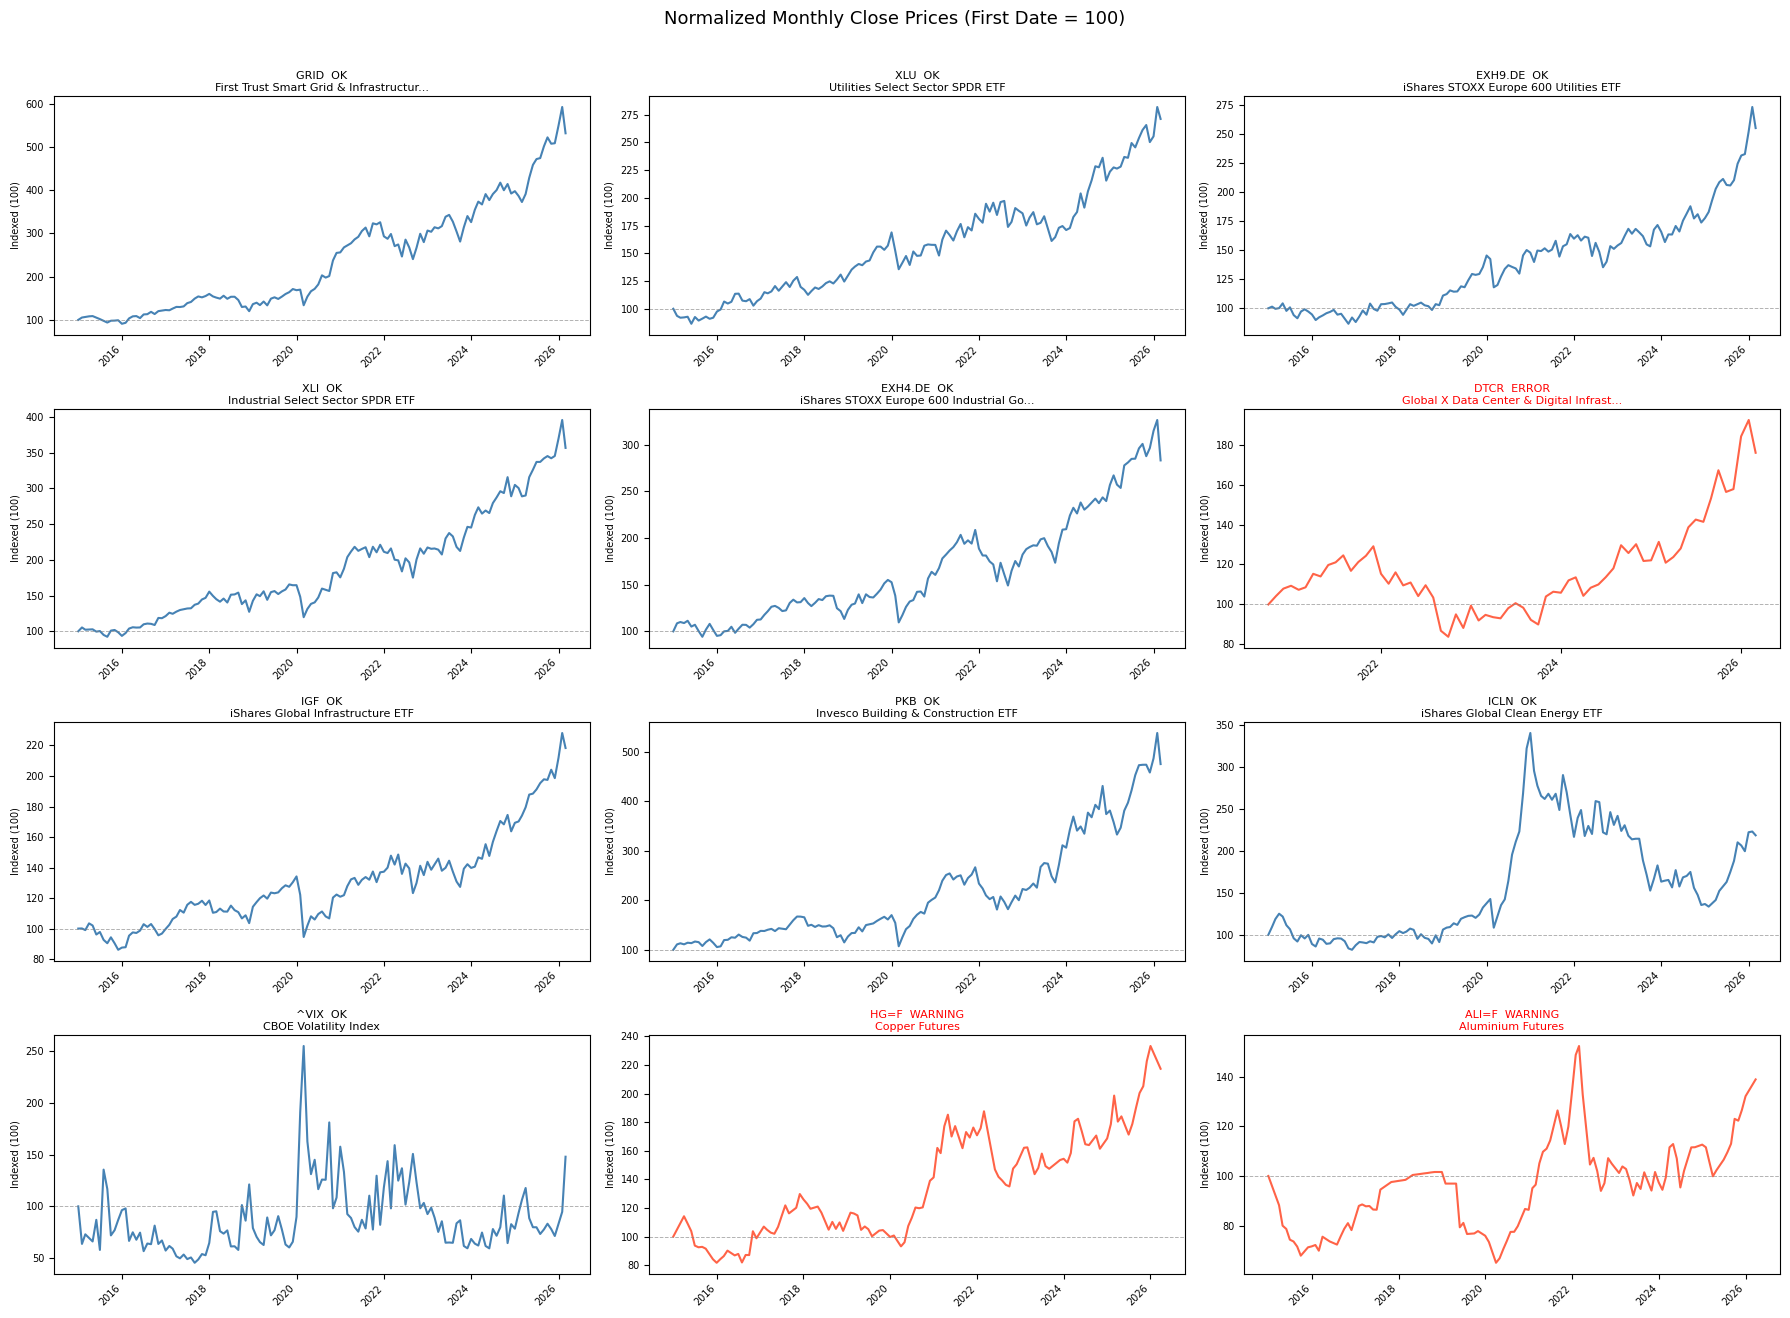

In [ ]:
# Plot normalized price series (4×3 grid)
status_map = {row["Ticker"]: row["Status"] for _, row in report_df.iterrows()}

fig, axes = plt.subplots(4, 3, figsize=(18, 13))
axes_flat = axes.flatten()

for i, (ticker, name) in enumerate(TICKERS.items()):
    ax = axes_flat[i]
    status = status_map.get(ticker, "ERROR")
    title_color = "red" if status in ("WARNING", "ERROR") else "black"

    if ticker in prices.columns and prices[ticker].notna().any():
        col = prices[ticker].dropna()
        normalized = col / col.iloc[0] * 100
        ax.plot(normalized.index, normalized.values, linewidth=1.5,
                color="steelblue" if status == "OK" else "tomato")
        ax.axhline(100, color="gray", linestyle="--", linewidth=0.7, alpha=0.6)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right", fontsize=7)
    else:
        ax.text(0.5, 0.5, "No data", transform=ax.transAxes,
                ha="center", va="center", color="red", fontsize=12)

    short_name = name[:38] + "..." if len(name) > 38 else name
    ax.set_title(f"{ticker}  {status}\n{short_name}",
                 fontsize=8, color=title_color, pad=4)
    ax.set_ylabel("Indexed (100)", fontsize=7)
    ax.tick_params(axis="y", labelsize=7)

plt.suptitle("Normalized Monthly Close Prices (First Date = 100)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 5. Monthly Returns

We compute percentage changes (`pct_change()`) on the price series to obtain monthly returns.
Returns are stationary and scale-invariant — preferred over raw prices as model features.

In [ ]:
# Calculate monthly returns from close prices
returns = prices.pct_change()

print(f"Returns shape: {returns.shape}")
print(f"Date range:    {returns.index.min().date()} → {returns.index.max().date()}")
print(f"NaN per column (first 5 rows excluded):\n{returns.iloc[1:].isna().sum().to_string()}")
returns.head()

Returns shape: (136, 12)
Date range:    2015-01-01 → 2026-03-27
NaN per column (first 5 rows excluded):
Ticker
GRID        0
XLU         0
EXH9.DE     0
XLI         0
EXH4.DE     0
DTCR       69
IGF         0
PKB         0
ICLN        0
^VIX        0
HG=F        0
ALI=F       0


/var/folders/gf/l4dv1kz57_j_y218rb491wp40000gn/T/ipykernel_8298/611623089.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


Ticker,GRID,XLU,EXH9.DE,XLI,EXH4.DE,DTCR,IGF,PKB,ICLN,^VIX,HG=F,ALI=F
Date,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,0.0544,-0.0639,0.0141,0.0535,0.0865,NaN,0.0007,0.1087,0.0952,-0.3639,0.0000,0.0000
2015-03-01,0.0126,-0.0177,-0.0187,-0.0299,0.0126,NaN,-0.0109,0.0203,0.0851,0.1462,0.0000,0.0000
2015-04-01,0.0132,0.0031,0.0061,0.0021,-0.0102,NaN,0.0447,-0.0186,0.0531,-0.0484,0.1418,-0.1178
2015-05-01,0.0054,0.0063,0.0412,0.0032,0.0225,NaN,-0.0135,0.0293,-0.0272,-0.0488,-0.0440,-0.0938


## 6. Lagged Features (Lag 1–6 months)

For each ticker and each lag from 1 to 6, we create a column `{ticker}_lag{n}` representing
the return `n` months before the current period. These are the features that will be merged
with the Siemens SI training data.

In [ ]:
# Generate lagged return features (lag 1 to 6)
lag_dict = {}

for ticker in TICKERS:
    if ticker not in returns.columns:
        continue
    for lag in range(1, 7):
        col_name = f"{ticker}_lag{lag}"
        lag_dict[col_name] = returns[ticker].shift(lag)

lagged_features = pd.DataFrame(lag_dict, index=returns.index)

print(f"Lagged features shape: {lagged_features.shape}")
print(f"  → {len(TICKERS)} tickers × 6 lags = {len(TICKERS) * 6} expected columns")
print(f"  → Actual columns: {lagged_features.shape[1]}")
lagged_features.head()

Lagged features shape: (136, 72)
  → 12 tickers × 6 lags = 72 expected columns
  → Actual columns: 72


,GRID_lag1,GRID_lag2,GRID_lag3,GRID_lag4,GRID_lag5,GRID_lag6,XLU_lag1,XLU_lag2,XLU_lag3,XLU_lag4,XLU_lag5,XLU_lag6,EXH9.DE_lag1,EXH9.DE_lag2,EXH9.DE_lag3,EXH9.DE_lag4,EXH9.DE_lag5,EXH9.DE_lag6,XLI_lag1,XLI_lag2,XLI_lag3,XLI_lag4,XLI_lag5,XLI_lag6,EXH4.DE_lag1,EXH4.DE_lag2,EXH4.DE_lag3,EXH4.DE_lag4,EXH4.DE_lag5,EXH4.DE_lag6,DTCR_lag1,DTCR_lag2,DTCR_lag3,DTCR_lag4,DTCR_lag5,DTCR_lag6,IGF_lag1,IGF_lag2,IGF_lag3,IGF_lag4,IGF_lag5,IGF_lag6,PKB_lag1,PKB_lag2,PKB_lag3,PKB_lag4,PKB_lag5,PKB_lag6,ICLN_lag1,ICLN_lag2,ICLN_lag3,ICLN_lag4,ICLN_lag5,ICLN_lag6,^VIX_lag1,^VIX_lag2,^VIX_lag3,^VIX_lag4,^VIX_lag5,^VIX_lag6,HG=F_lag1,HG=F_lag2,HG=F_lag3,HG=F_lag4,HG=F_lag5,HG=F_lag6,ALI=F_lag1,ALI=F_lag2,ALI=F_lag3,ALI=F_lag4,ALI=F_lag5,ALI=F_lag6
Date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2015-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-02-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2015-03-01,0.0544,NaN,NaN,NaN,NaN,NaN,-0.0639,NaN,NaN,NaN,NaN,NaN,0.0141,NaN,NaN,NaN,NaN,NaN,0.0535,NaN,NaN,NaN,NaN,NaN,0.0865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0007,NaN,NaN,NaN,NaN,NaN,0.1087,NaN,NaN,NaN,NaN,NaN,0.0952,NaN,NaN,NaN,NaN,NaN,-0.3639,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN,0.0000,NaN,NaN,NaN,NaN,NaN
2015-04-01,0.0126,0.0544,NaN,NaN,NaN,NaN,-0.0177,-0.0639,NaN,NaN,NaN,NaN,-0.0187,0.0141,NaN,NaN,NaN,NaN,-0.0299,0.0535,NaN,NaN,NaN,NaN,0.0126,0.0865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0109,0.0007,NaN,NaN,NaN,NaN,0.0203,0.1087,NaN,NaN,NaN,NaN,0.0851,0.0952,NaN,NaN,NaN,NaN,0.1462,-0.3639,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN,0.0000,0.0000,NaN,NaN,NaN,NaN
2015-05-01,0.0132,0.0126,0.0544,NaN,NaN,NaN,0.0031,-0.0177,-0.0639,NaN,NaN,NaN,0.0061,-0.0187,0.0141,NaN,NaN,NaN,0.0021,-0.0299,0.0535,NaN,NaN,NaN,-0.0102,0.0126,0.0865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0447,-0.0109,0.0007,NaN,NaN,NaN,-0.0186,0.0203,0.1087,NaN,NaN,NaN,0.0531,0.0851,0.0952,NaN,NaN,NaN,-0.0484,0.1462,-0.3639,NaN,NaN,NaN,0.1418,0.0000,0.0000,NaN,NaN,NaN,-0.1178,0.0000,0.0000,NaN,NaN,NaN


## 7. Missing Value Heatmap

Binary heatmap showing where NaNs are concentrated in the lagged feature matrix.
This is especially important to check for newer ETFs like DTCR (launched ~2021),
which will have large NaN blocks at the top of the feature matrix.

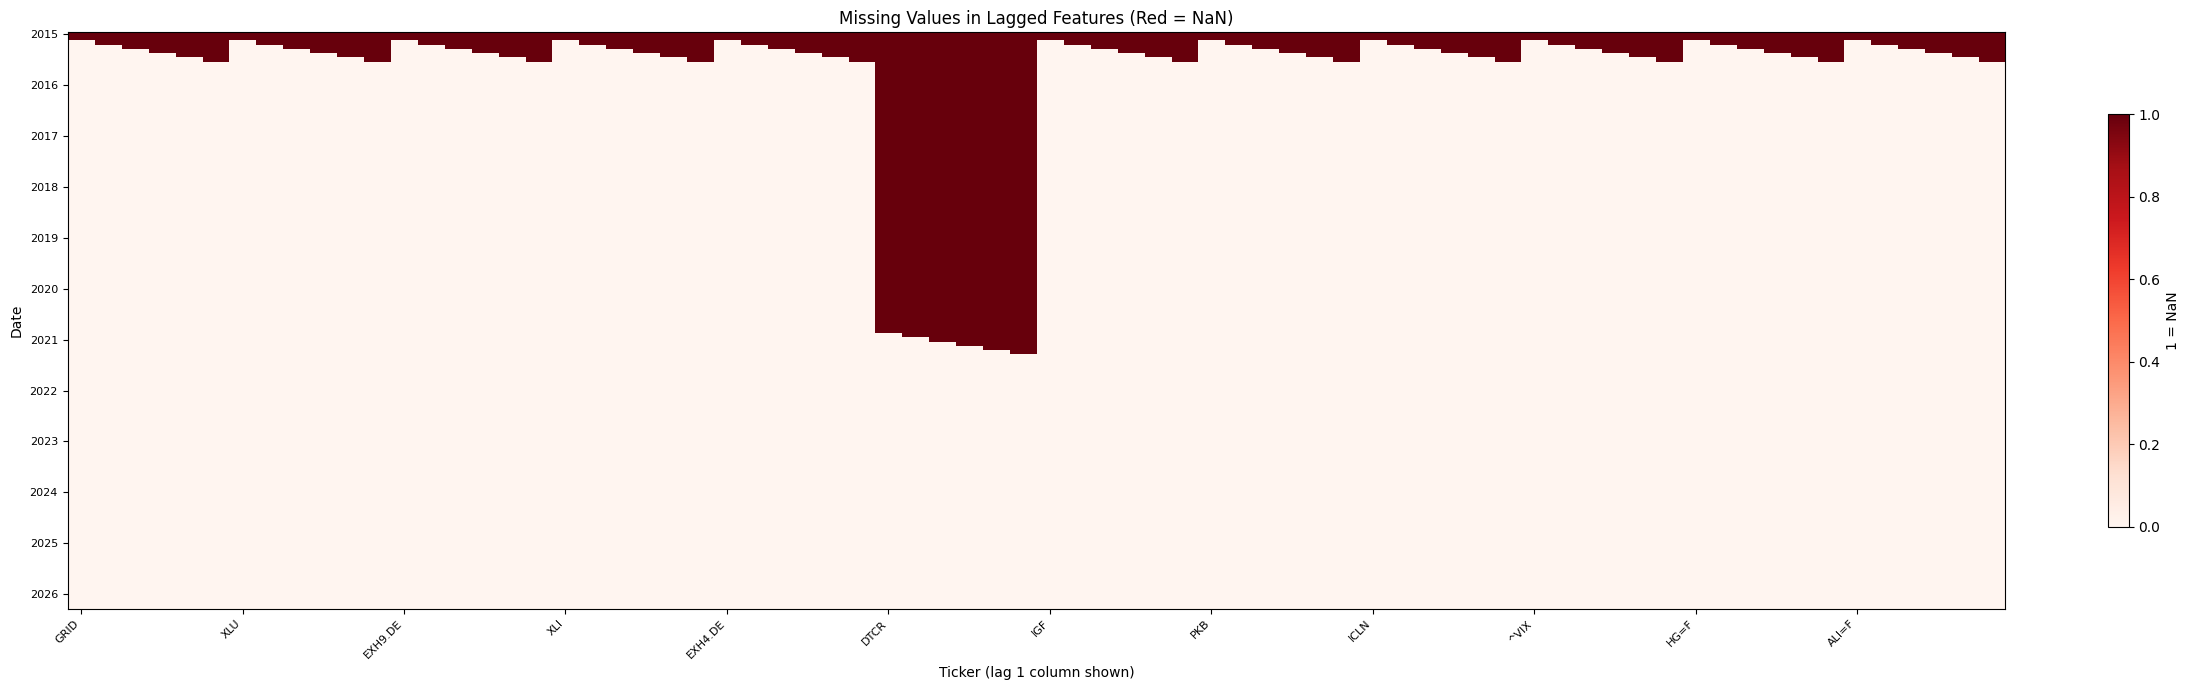

In [ ]:
# Missing value heatmap for lagged features
nan_matrix = lagged_features.isna().astype(int).values

fig, ax = plt.subplots(figsize=(22, 7))
im = ax.imshow(nan_matrix, aspect="auto", cmap="Reds", interpolation="none",
               vmin=0, vmax=1)

# X axis: feature column names (every 6th = one per ticker)
ax.set_xticks(range(0, lagged_features.shape[1], 6))
ax.set_xticklabels(
    [col.replace("_lag1", "") for col in lagged_features.columns[::6]],
    rotation=45, ha="right", fontsize=8
)

# Y axis: dates (every 12 months)
year_ticks = range(0, len(lagged_features), 12)
ax.set_yticks(list(year_ticks))
ax.set_yticklabels(
    [str(lagged_features.index[i].year) for i in year_ticks],
    fontsize=8
)

ax.set_title("Missing Values in Lagged Features (Red = NaN)", fontsize=12)
ax.set_xlabel("Ticker (lag 1 column shown)")
ax.set_ylabel("Date")
plt.colorbar(im, ax=ax, fraction=0.01, label="1 = NaN")
plt.tight_layout()
plt.show()

## 5. Exploratory Data Analysis

We explore the cumulative returns and the correlation of monthly returns between the different valid market indices to understand their relationships and potential complementary value as features.

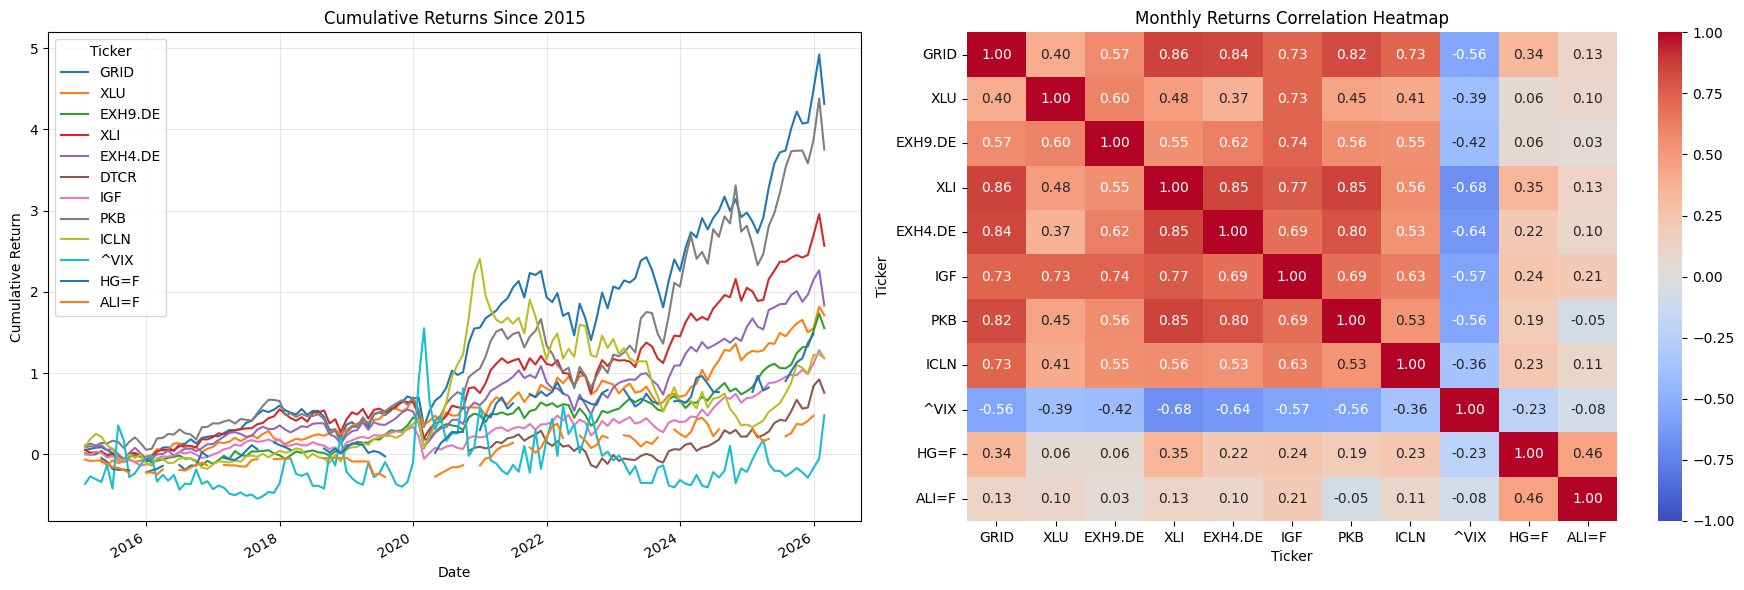

In [ ]:
# Cumulative Returns & Correlation Heatmap
import seaborn as sns

# Calculate cumulative returns
cumulative_returns = (1 + prices.pct_change(fill_method=None)).cumprod() - 1

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Plot cumulative returns
cumulative_returns.plot(ax=axes[0])
axes[0].set_title('Cumulative Returns Since 2015')
axes[0].set_ylabel('Cumulative Return')
axes[0].grid(True, alpha=0.3)

# Filter out the ERROR ticker (DTCR) for correlation
valid_tickers = [t for t in prices.columns if t != 'DTCR']
corr_matrix = prices[valid_tickers].pct_change(fill_method=None).corr()

# Plot correlation heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Monthly Returns Correlation Heatmap')

plt.tight_layout()
plt.show()